# Evaluate **Paraphrasing**

Our imposter approach needs models to reword an original text keeping the same meaning.
Ideally, we want to model the way texts originated.
This is dependent on the text's genre, i.e. a student essay originates from a task description and a list of URLs while a new article originates from a list of additional sources or from spectating an event.
We implemented both a naive approach to rewording a text and a more sophisticated one:
- given a prompt and a text, the naive approach uses a language model to paraphrase the text
- given a prompt and a text LLM A is used to extract the text's genre, tone and summary of bullet points, then LLM B is used to reword the text in the same genre and tone based on the summary of bullet points

In [1]:
from pathlib import Path
import os
import textwrap
import sys
import pandas as pd

# Add the root of the project to Python path
sys.path.append(os.path.abspath(".."))
from config import CONFIG
from genai_detection.paraphrasing.paraphraser import (
    T5ChatGPTParaphraser,
    T5GooglePAWSParaphraser,
    BlabladorParaphraser,
    BulletPointParaphraser,
    OllamaParaphraser,
    TaskParaphraser,
    TopicParaphraser,
    TitleParaphraser,
)
from genai_detection.paraphrasing.paraphraser_evaluation import ParaphrasingEvaluator

/Users/klara/Library/Caches/pypoetry/virtualenvs/generative-ai-detection-PkLo9Jli-py3.11/lib/python3.11/site-packages/pyemd/__init__.py:74: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from .emd import emd, emd_with_flow, emd_samples
[nltk_data] Downloading package wordnet to /Users/klara/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Original text
We use a CNN news article from 23.06.2025/ 04.07.2025 as an example.

In [8]:
USE_GROUND_TRUTH = True  # If True, use ground truth metadata from the dataset (if present), otherwise use LLM extracted metadata
path2results = Path(os.getcwd()).resolve().parent / CONFIG.SAVE_PATH / "paraphrasing"
category2directory = {  # value: directory name and one file name in the datasets folder
    "News": [
        "custom_texts",
        "cnn_040725",
    ],  # Dalai Lama; "cnn_230625"    # USA attacks Iran
    "Blog": ["blog_corpus", 27],
    "Gutenberg": ["gutenberg", "Othello_the_Moor_of_Venice_William_Shakespeare"],
    "Student Essay": [
        "student_essays/Intro2006",
        "Ass1/2006_AB4847",
    ],  # stream of consciousness essay: 18 years old girl who writes about her bipolar ex-boyfriend of 8 months and her new boyfriend who loves music like her but is not catholic; she wants to live in the present
}

# This is used for plot titles in the notebook
# data_category = "Blog"
# data_category = "News"
data_category = "Gutenberg"
data_category = "Student Essay"
path2datasets = (
    Path(os.getcwd()).resolve().parent
    / "data"
    / "datasets"
    / category2directory[data_category][0]
)
if data_category not in ["News", "Gutenberg"] and USE_GROUND_TRUTH:
    # Student Essay dataset has metadata, but none of the information we extract, hence we set USE_GROUND_TRUTH to False
    print(
        f"Data category {data_category} has no metadata file, USE_GROUND_TRUTH was set to False."
    )
    USE_GROUND_TRUTH = False
path2metadata = path2datasets / "file_metadata.xlsx"
assert path2datasets.exists(), f"Path to datasets {path2datasets} does not exist."
assert path2results.exists(), f"Path to results {path2results} does not exist."

file_name = category2directory[data_category][1]
original_text = (
    open(path2datasets / f"{file_name}.txt").read()
    if data_category != "Blog"
    else pd.read_csv(path2datasets / f"blogtext.csv").loc[file_name, "text"]
)
metadata = (
    pd.read_excel(path2metadata, index_col="filename").loc[file_name].dropna().to_dict()
    if USE_GROUND_TRUTH
    else {}
)
print(f"Metadata for {file_name}: {metadata}")

print(textwrap.fill(original_text, width=80))

Data category Student Essay has no metadata file, USE_GROUND_TRUTH was set to False.
Metadata for Ass1/2006_AB4847: {}
The thoughts, feelings, and perceptions that occur in my mind. Strangely enough,
what I have been continually thinking about today has been psychology class.
Recently, my boyfriend of 8 months ended our relationship while he was in Rome,
Italy. I believe we were having rough times, but neither of us seemed to be the
"giving up" type. Its fascinating to think that we ended up doing what we never
thought we would.   He came back from Rome and we went out to dinner, and it was
as though we hadn't really broken up. It was fascinating to me because we were
closer than ever. Then he kept continually changing his mind. He would just call
me randomly and say he thought it was wrong that we were dating or that our
relationship meant nothing to him. It would definitely upset me at the time, and
I'm not exactly sure why I put up with it, but I guess it was because I cared
about h

## Naive Approach

In [3]:
ollama_version = "zephyr:7b"  # "mistral:7b"  # "default:latest"
paraphrasers = {
    "T5_ChatGPT": T5ChatGPTParaphraser(),
    "T5_Google_PAWS": T5GooglePAWSParaphraser(),
    # "Blablador": BlabladorParaphraser(
    #     model_id="1 - Llama3 405 the best general model and big context size"
    # ),
    "Ollama": OllamaParaphraser(model_id=ollama_version),
}
if "Blablador" in paraphrasers.keys():
    print(
        "Available Blablador models:\n",
        paraphrasers["Blablador"]._get_available_models(verbose=False),
    )

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [4]:
n_responses = 1  # number of paraphrases to generate
max_length = 512  # Maximum length of the generated paraphrase
temperature = 0.7  # Controls the randomness of the output. Lower values make the output more deterministic.

prompts = [
    "Paraphrase the text above and output only the paraphrased version.",
    "For the text above: First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts).",
    "For the text above: Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.",
    "For the text above: Paraphrase the sentence using the same tone as the original with approximately the same number of words.",
    "For the text above: Paraphrase this sentence. Do not change the meaning, but use different words and structure. Output only the paraphrased sentence.",
]

## Bullet Point Approach

Ollama models are by far the best ones for extracting the genre, tone and summary of bullet points and returning them in a structured way.
Hence, we use the Ollama model as the text extractor and any other model as the text generator.

In [5]:
models = {
    "text_extractor": {
        "name": "Ollama-latest",
        "model": OllamaParaphraser(model_id=ollama_version),
    },
    "text_generator": {
        "name": "Ollama-latest",
        "model": OllamaParaphraser(model_id=ollama_version),
    },
}
bullet_point_paraphraser = BulletPointParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Task Paraphraser
The task paraphraser extracts the task, tone and genre from the text and then generates a paraphrase based on this information.

In [6]:
task_paraphraser = TaskParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Topic Paraphraser
The topic paraphraser extracts the topic, tone and genre from the text and then generates a paraphrase based on this information.

In [7]:
topic_paraphraser = TopicParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Title Paraphraser
The title paraphraser extracts the title, tone and genre from the text and then generates a paraphrase based on this information.

In [8]:
title_paraphraser = TitleParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Evaluating the Approaches

In [9]:
paraphrasers.update(
    {
        "BulletPoint": bullet_point_paraphraser,
        "Task": task_paraphraser,
        "Topic": topic_paraphraser,
        "Title": title_paraphraser,
    }
)

paraphrase_evaluator = ParaphrasingEvaluator(
    paraphrasers=paraphrasers,
    prompts=prompts,
    original_text=original_text,
    n_responses=n_responses,
    max_length=max_length,
    temperature=temperature,
    ground_truth=metadata,  # if USE_GROUND_TRUTH else None
)
df, extremest_paraphrases = paraphrase_evaluator.evaluate(
    save_extremest_paraphr_per_score=True, save_to_disk=True
)
display(df)

[DEBUG] Total configurations to evaluate: 35, [(('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x33dc5d890>), 'Paraphrase the text above and output only the paraphrased version.', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x33dc5d890>), 'For the text above: First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts).', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x33dc5d890>), 'For the text above: Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x33dc5d890>), 'For the text

Evaluating Paraphrasers:  60%|██████    | 21/35 [04:58<06:16, 26.87s/it]

Again
Again
Again
Again


Evaluating Paraphrasers:  63%|██████▎   | 22/35 [06:31<10:06, 46.62s/it]

Again


...

Evaluating Paraphrasers:  91%|█████████▏| 32/35 [11:47<00:55, 18.55s/it]

Again


ERROR:genai_detection.paraphrasing.paraphraser_evaluation:[ERROR] Paraphraser 'Title' with prompt 'None' failed: not enough values to unpack (expected 7, got 6)
Evaluating Paraphrasers: 100%|██████████| 35/35 [11:56<00:00, 20.48s/it]

Results saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_results_comparison_temp0.7_maxLength512.csv


,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta
0,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,0.042414,0.815275,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066
1,T5_ChatGPT,"For the text above: First, extract bullet poin...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,0.042414,0.815275,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066
2,T5_ChatGPT,For the text above: Paraphrase the sentence by...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,0.042414,0.815275,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066
3,T5_ChatGPT,For the text above: Paraphrase the sentence us...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,0.042414,0.815275,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066
4,T5_ChatGPT,For the text above: Paraphrase this sentence. ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,0.042414,0.815275,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066
5,T5_Google_PAWS,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the dalai lama announced that after his 90th b...,1.659137e-04,0.088640,0.180704,0.141321,0.150077,0.150077,0.844347,0.727562,0.781616,0.162368,0.908396,distilbert-base-uncased_L5_no-idf_version=0.3....,0.684858,0.110316,0.574542
6,T5_Google_PAWS,"For the text above: First, extract bullet poin...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the dalai lama has been the living embodiment ...,2.343179e-04,0.092546,0.192661,0.165644,0.174312,0.174312,0.872495,0.727462,0.793405,0.144592,0.810260,distilbert-base-uncased_L5_no-idf_version=0.3....,0.669643,0.122402,0.547240
7,T5_Google_PAWS,For the text above: Paraphrase the sentence by...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the dalai lama declared on wednesday that afte...,2.259045e-04,0.071862,0.179878,0.113150,0.146341,0.146341,0.862831,0.725417,0.788180,0.148872,0.928470,distilbert-base-uncased_L5_no-idf_version=0.3....,0.690754,0.108815,0.581939
8,T5_Google_PAWS,For the text above: Paraphrase the sentence us...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the dalai lama has been the living embodiment ...,2.402461e-04,0.083450,0.192661,0.165644,0.174312,0.174312,0.922194,0.737183,0.819375,0.138034,0.822450,distilbert-base-uncased_L5_no-idf_version=0.3....,0.687847,0.122404,0.565443
9,T5_Google_PAWS,For the text above: Paraphrase this sentence. ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","fo

In [10]:
df["paraphrased_text"].values

array(['despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.',
       'despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.',
       'despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.',
       'despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.',
       'despite the challenges of political unrest in tibet, the dalai lama has emerged as one of the most influential figures in tibetan buddhism.',
       'the dalai lama announced that after his 90th birthday he will have a successor in the free world outside china. it has become a symbolic event for tibetan buddhism, which is defined by a distinct language, culture, religion and way of life th

### Extremest (i.e. best and worst) paraphrases per metric

In [11]:
display(extremest_paraphrases)

,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,...,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta,metric,extreme
0,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,bleu_score,min
1,Ollama,"For the text above: First, extract bullet poin...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","- the dalai lama, spiritual leader of tibetan ...",2.224235e-01,0.379518,0.611174,0.498286,0.476625,...,0.822665,0.840420,0.354260,0.919542,distilbert-base-uncased_L5_no-idf_version=0.3....,0.759169,0.436741,0.322428,bleu_score,max
2,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,meteor_score,min
3,Ollama,"For the text above: First, extract bullet poin...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","- the dalai lama, spiritual leader of tibetan ...",2.224235e-01,0.379518,0.611174,0.498286,0.476625,...,0.822665,0.840420,0.354260,0.919542,distilbert-base-uncased_L5_no-idf_version=0.3....,0.759169,0.436741,0.322428,meteor_score,max
4,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,rouge1,min
5,Ollama,"For the text above: First, extract bullet poin...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","- the dalai lama, spiritual leader of tibetan ...",2.224235e-01,0.379518,0.611174,0.498286,0.476625,...,0.822665,0.840420,0.354260,0.919542,distilbert-base-uncased_L5_no-idf_version=0.3....,0.759169,0.436741,0.322428,rouge1,max
6,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,rouge2,min
7,Ollama,"For the text above: First, extract bullet poin...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","- the dalai lama, spiritual leader of tibetan ...",2.224235e-01,0.379518,0.611174,0.498286,0.476625,...,0.822665,0.840420,0.354260,0.919542,distilbert-base-uncased_L5_no-idf_version=0.3....,0.759169,0.436741,0.322428,rouge2,max
8,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political unrest in ...,5.257107e-12,0.015206,0.052202,0.019640,0.042414,...,0.665265,0.732670,0.075656,0.834160,distilbert-base-uncased_L5_no-idf_version=0.3....,0.624605,0.031539,0.593066,rougeL,min
9,Ollama,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","for almost a century, the dalai lama has been ..

In [12]:
print("### Extremest (i.e. best and worst) paraphrases per metric")
print("Original text:")
print(textwrap.fill(original_text[:200], width=80), "...")

for index, row in extremest_paraphrases.iterrows():
    print(f"Metric: {row['extreme']} {row['metric']}")
    print(
        f"Paraphrase by {row['model']}: {textwrap.fill(row['paraphrased_text'], width=80)}"
    )
    # print(f"Prompt: {row['prompt']}")
    print("-" * 80)

### Extremest (i.e. best and worst) paraphrases per metric
Original text:
  For much of the past century, the Dalai Lama has been the living embodiment of
Tibet’s struggle for greater freedoms under Chinese Communist Party rule,
sustaining the cause from exile even as an in ...
Metric: min bleu_score
Paraphrase by T5_ChatGPT: despite the challenges of political unrest in tibet, the dalai lama has emerged
as one of the most influential figures in tibetan buddhism.
--------------------------------------------------------------------------------
Metric: max bleu_score
Paraphrase by Ollama: - the dalai lama, spiritual leader of tibetan buddhism and symbol of tibet's
struggle for freedom under chinese rule, will have a successor after his death
and the office responsible for identifying his reincarnation will be solely
authorized. - the dalai lama has announced this in light of the historic battle
over who will control his reincarnation, which has become a pivotal point for
the future of ti

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_metrics_grouped_by_model_radar_chart_20250723_133351.png


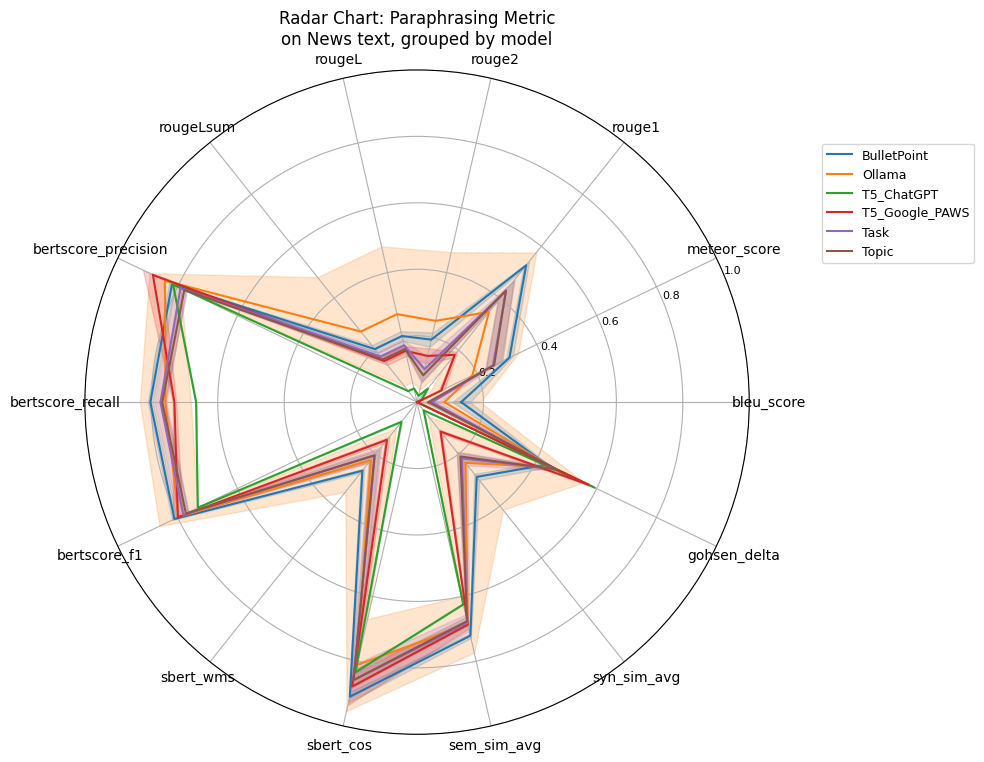

In [13]:
paraphrase_evaluator.plot_models_metrics(
    df=df, save_path=path2results, data_category=data_category, group_by="model"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_metrics_grouped_by_prompt_radar_chart_20250723_133352.png


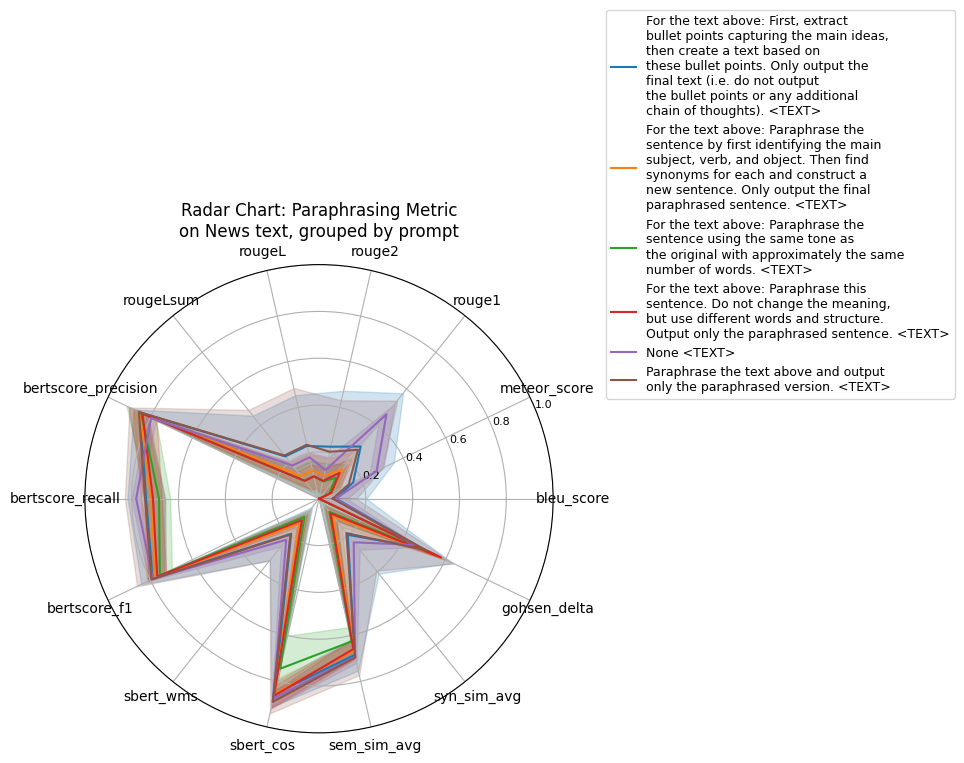

In [14]:
paraphrase_evaluator.plot_models_metrics(
    df=df, save_path=path2results, data_category=data_category, group_by="prompt"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/sem_syn_scatter_grouped_by_model_20250723_133352.png


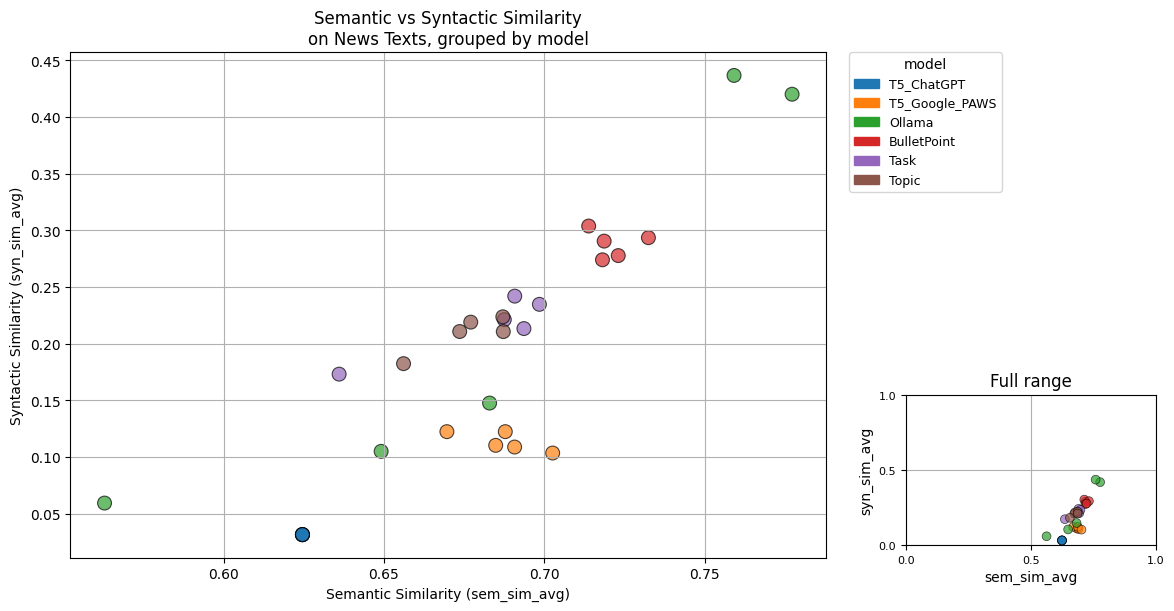

In [15]:
paraphrase_evaluator.plot_metric_scatter(
    df, save_path=path2results, data_category=data_category, group_by="model"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/sem_syn_scatter_grouped_by_prompt_20250723_133352.png


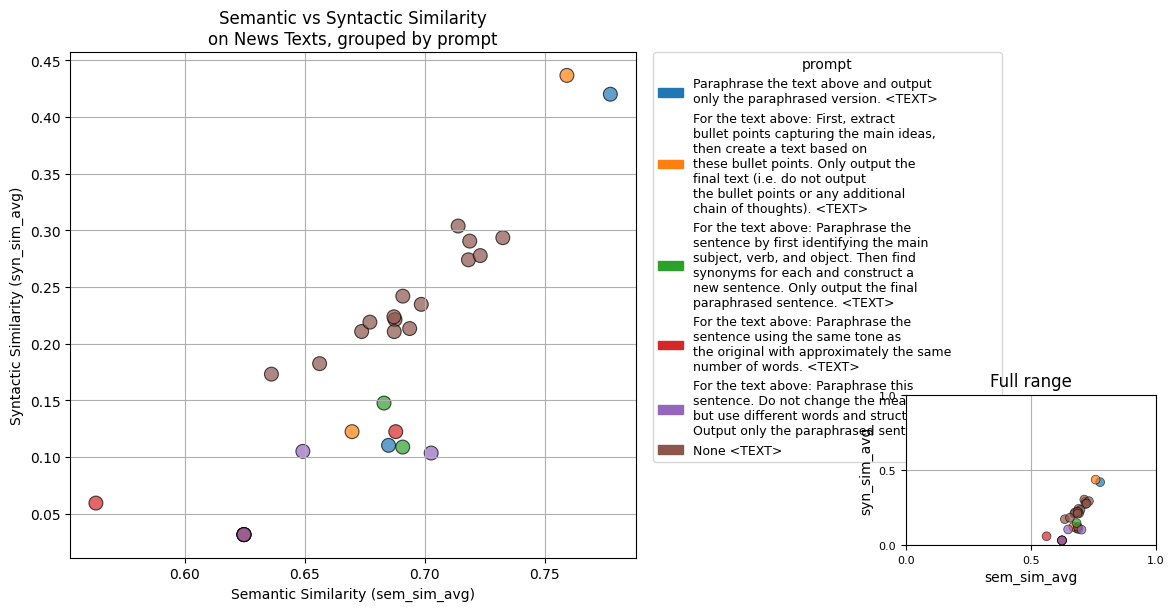

In [16]:
paraphrase_evaluator.plot_metric_scatter(
    df, save_path=path2results, data_category=data_category, group_by="prompt"
)

### Kernel Density Estimation (KDE)
- KDE estimates probability density PDF
- The y-axis is density/ concentration/ likelihood, not probability.
- Density can be greater than 1 if data are tightly clustered in a small range.
- For example, if many data points lie very close together, the curve can be sharp and tall (high density), so y-values exceed 1.
- The important property is that the **integral (area) under the curve is 1**, not that the max height is ≤1.

/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser_evaluation.py:1047: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser_evaluation.py:1047: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser_evaluation.py:1047: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser_evaluation.py:1047: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable t

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/metric_distributions_grouped_by_model_20250723_133353.png


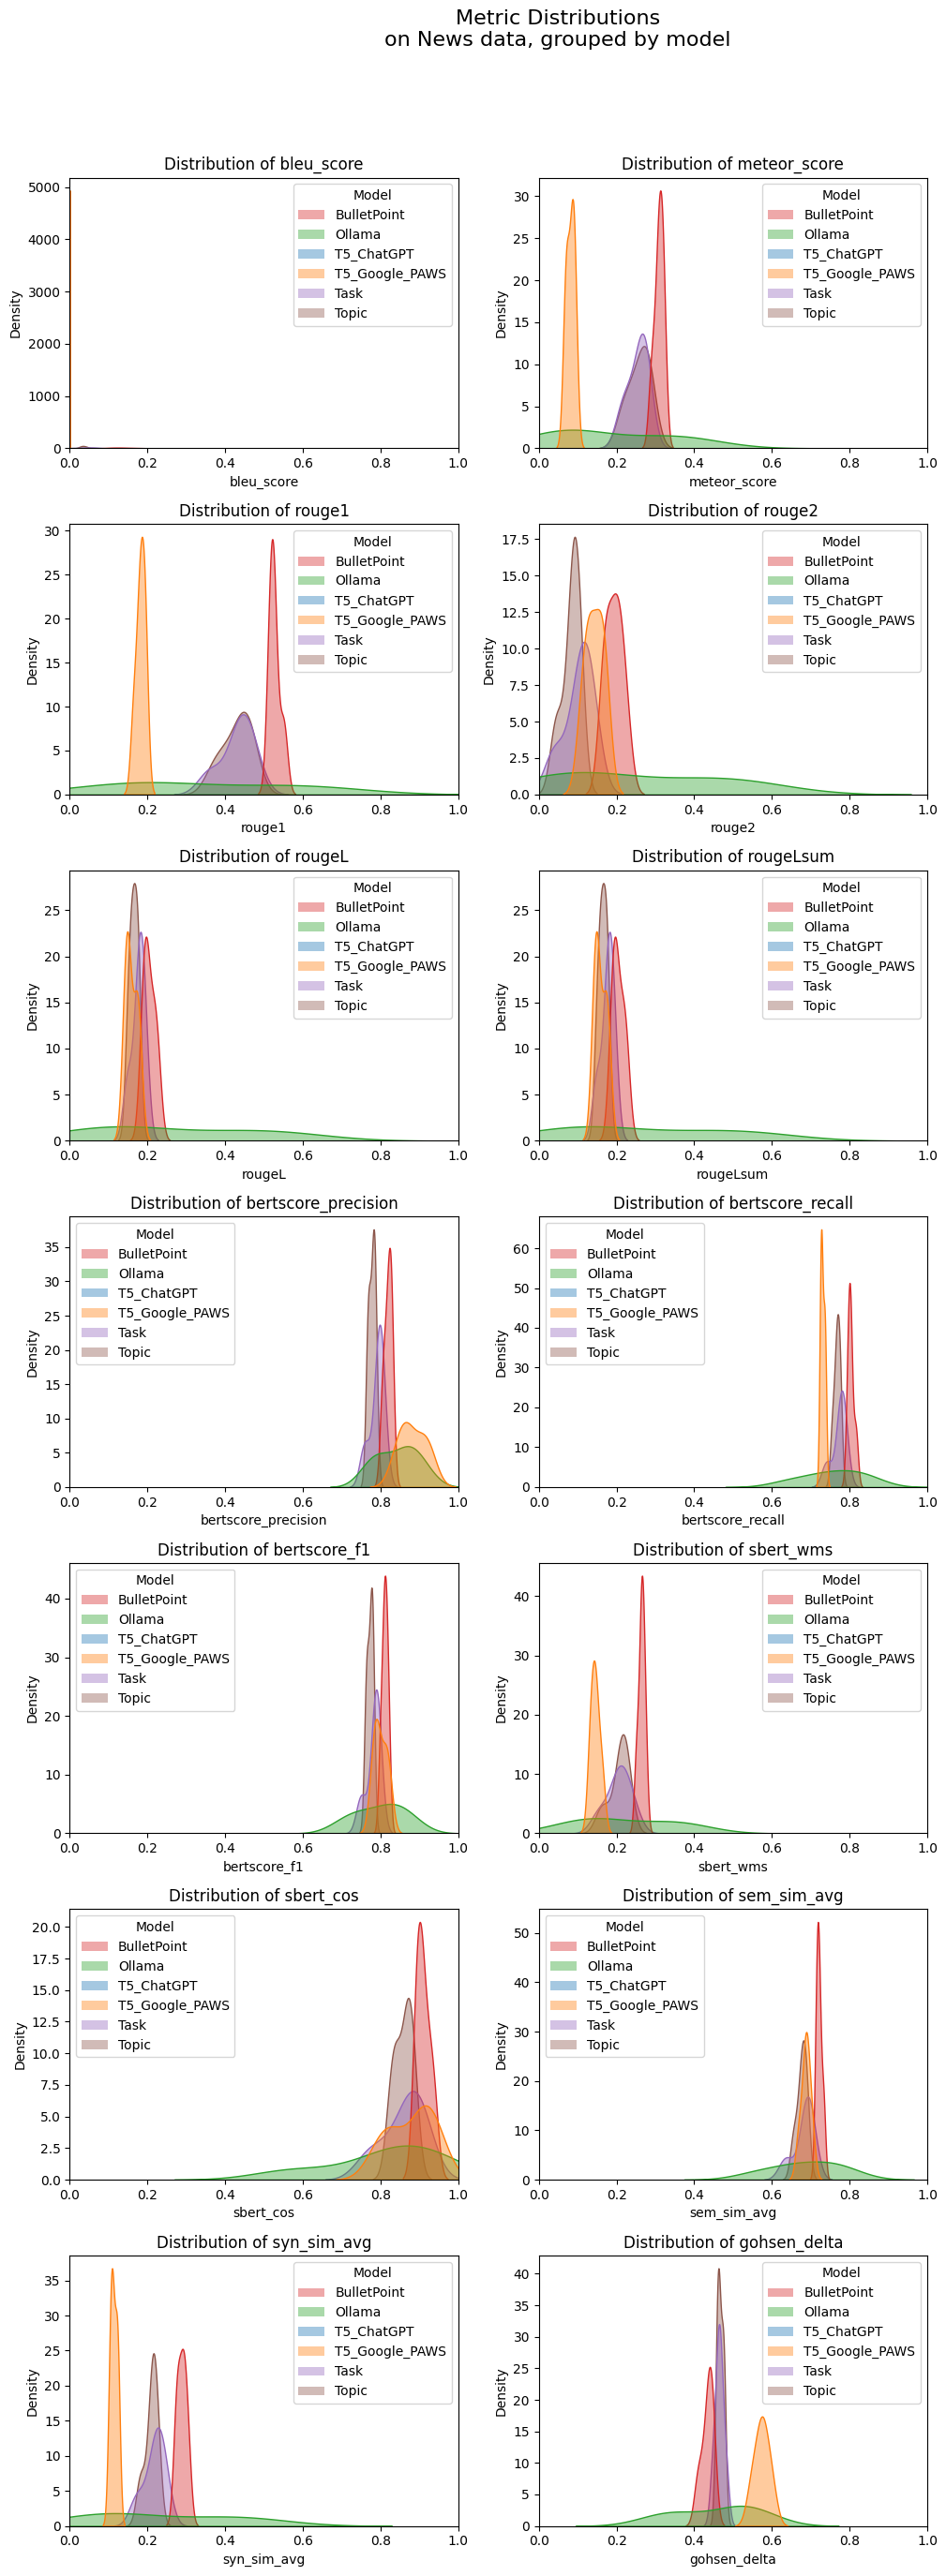

In [17]:
paraphrase_evaluator.plot_metric_distributions(
    df, save_path=path2results, data_category=data_category, group_by="model"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/metric_distributions_grouped_by_prompt_20250723_133355.png


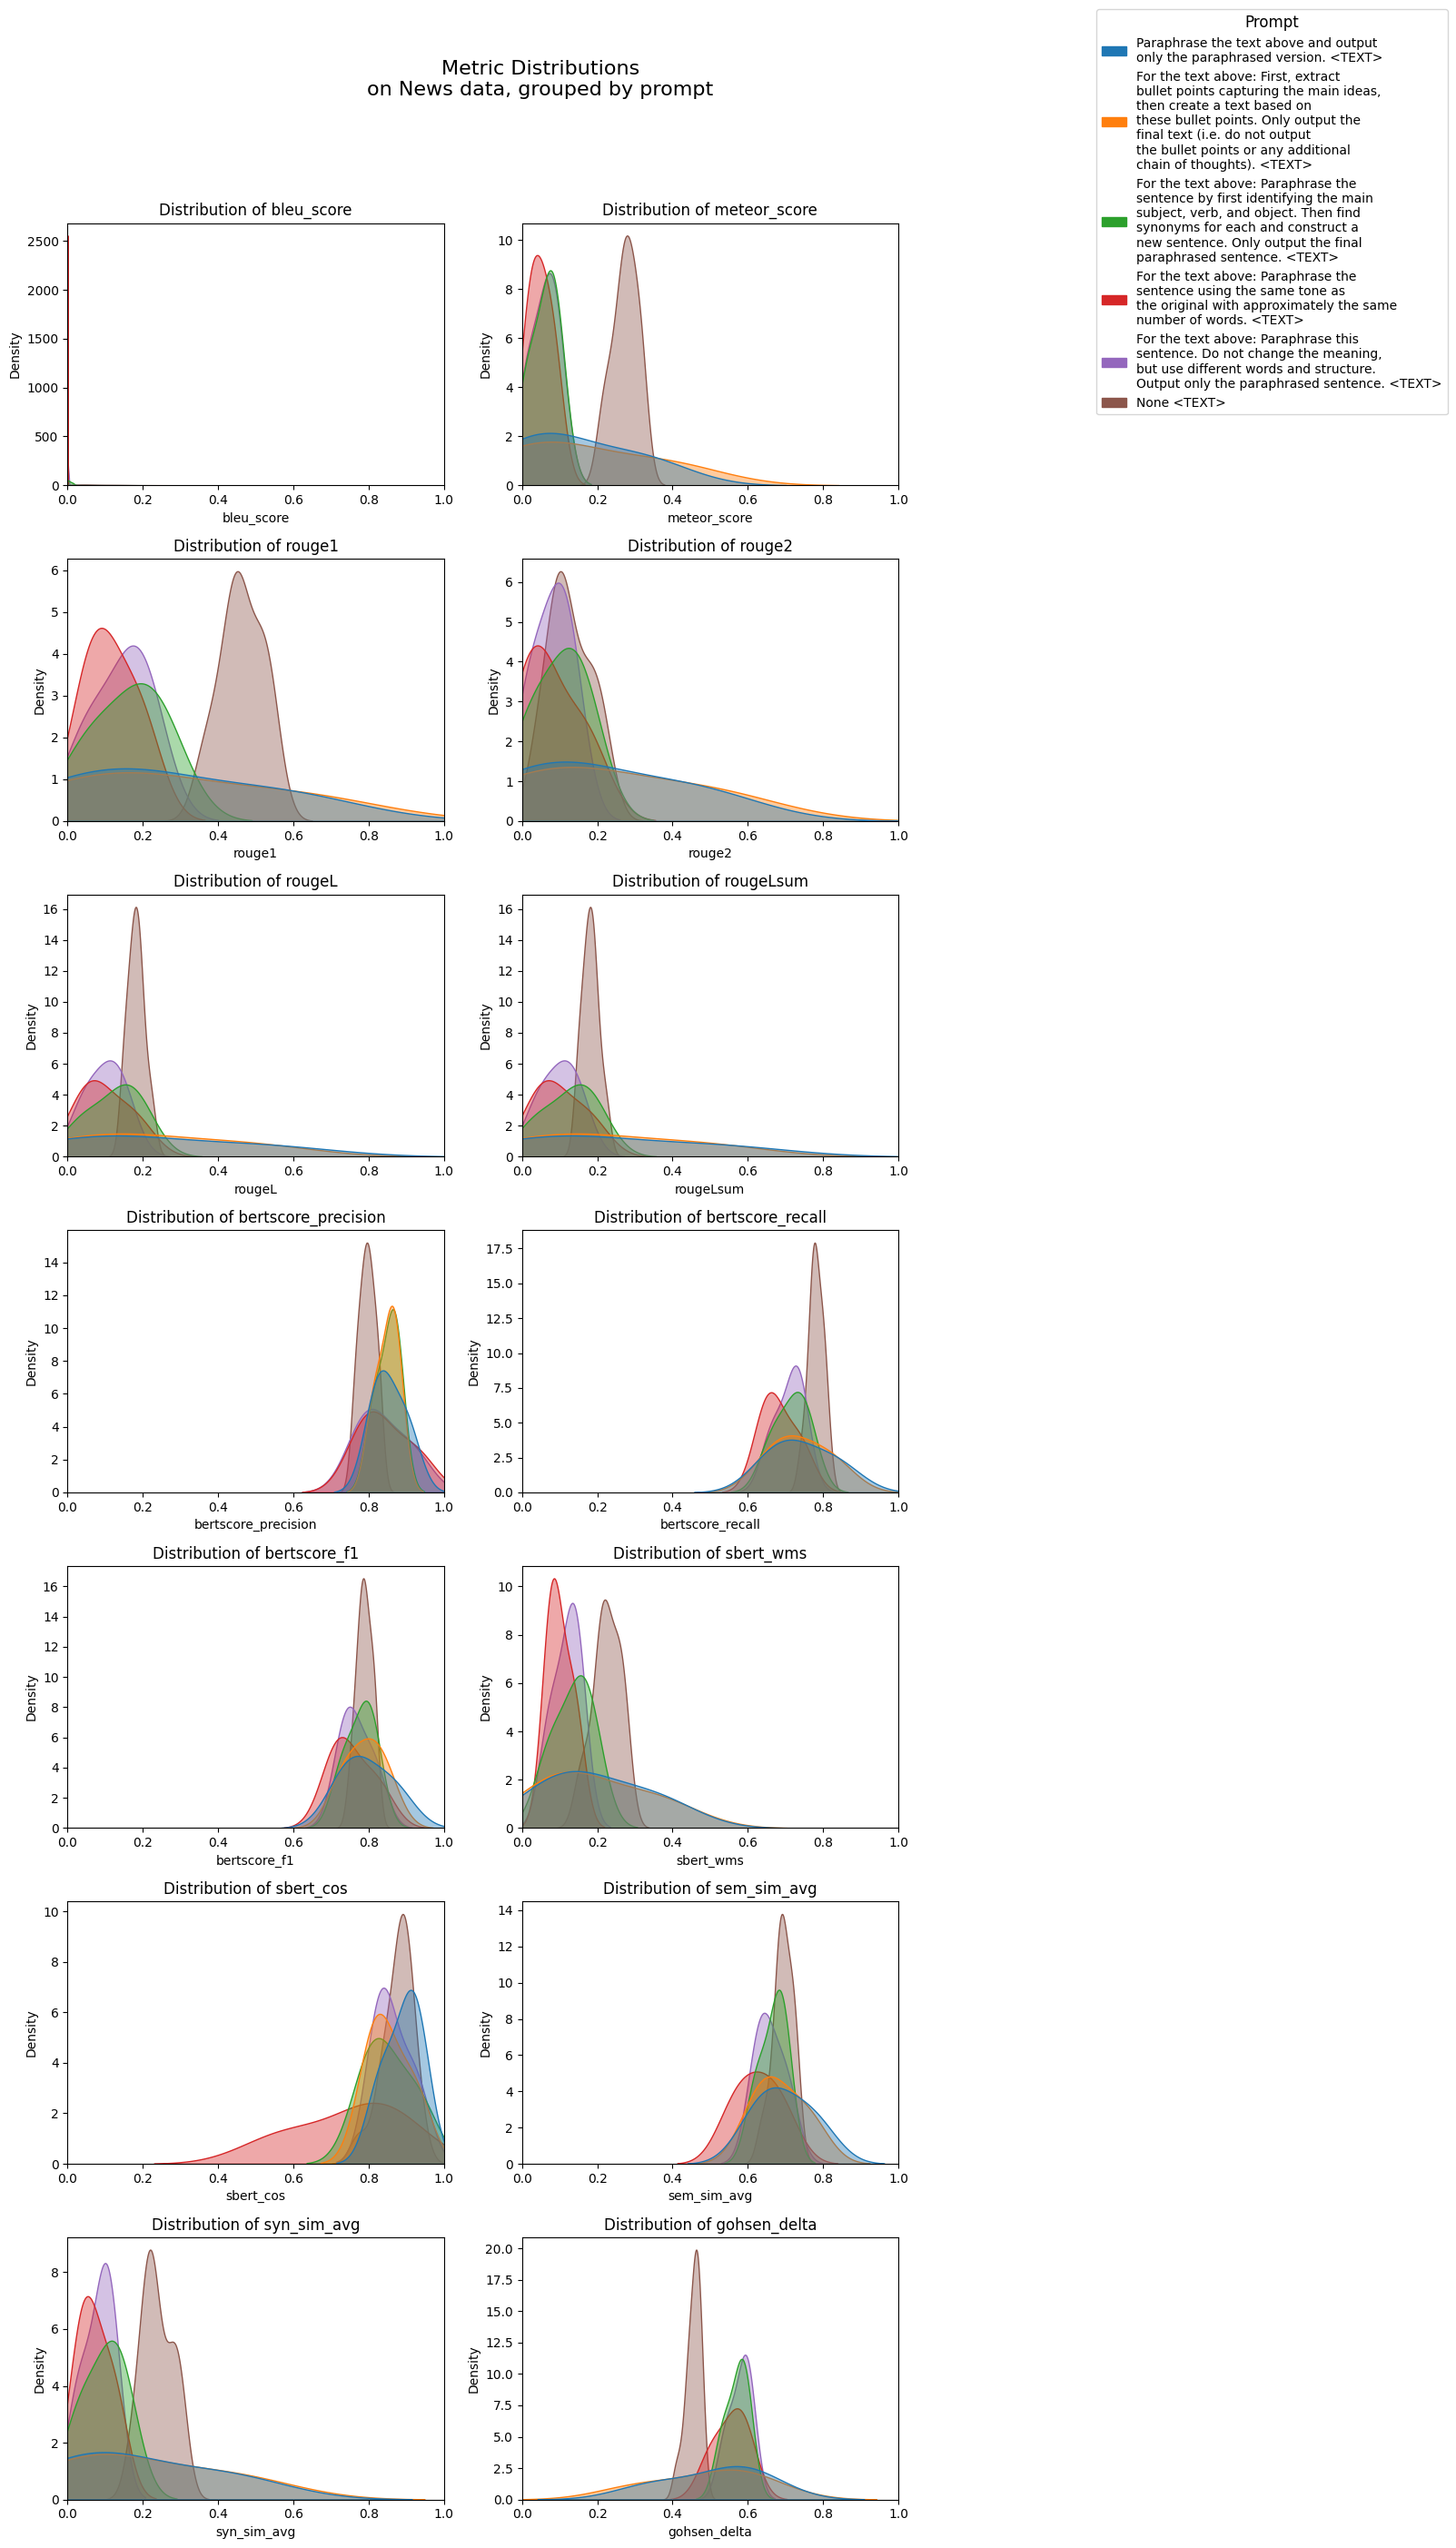

In [18]:
paraphrase_evaluator.plot_metric_distributions(
    df, save_path=path2results, data_category=data_category, group_by="prompt"
)

# Evaluation for text extractor of Non-Naive Paraphrasers

In [9]:
n_responses = 3  # number of paraphrases to generate
paraphrasers = {
    # "Ollama": OllamaParaphraser(model_id=ollama_version),
    "TopicParaphraser": TopicParaphraser(
        text_extractor=OllamaParaphraser(model_id=ollama_version),
        text_generator=OllamaParaphraser(model_id=ollama_version),
    ),
    # "TaskParaphraser": TaskParaphraser(
    #     text_extractor=OllamaParaphraser(model_id=ollama_version),
    #     text_generator=OllamaParaphraser(model_id=ollama_version),
    # ),
    # "TitleParaphraser": TitleParaphraser(
    #     text_extractor=OllamaParaphraser(model_id=ollama_version),
    #     text_generator=OllamaParaphraser(model_id=ollama_version),
    # ),
    # "BulletPointParaphraser": BulletPointParaphraser(
    #     text_extractor=OllamaParaphraser(model_id=ollama_version),
    #     text_generator=OllamaParaphraser(model_id=ollama_version),
    # ),
}
evaluator = ParaphrasingEvaluator(
    paraphrasers=paraphrasers,
    prompts=[
        "Paraphrase the following text and output only the paraphrased version:"
    ],  # use a single prompt for simplicity
    original_text="not used",  # self.base_dir contains fixed texts to test on
    n_responses=n_responses,
    max_length=max_length,
    temperature=temperature,
    config={"save_path": path2results},
)

In [10]:
evaluator.evaluate_extractors(save_to_disk=True)

Dataset snapshot:
         id gender  age              topic      sign          date  \
2   2059027   male   15            Student       Leo   12,May,2004   
5   3581210   male   33  InvestmentBanking  Aquarius  10,June,2004   
12  3581210   male   33  InvestmentBanking  Aquarius  09,June,2004   
19  3581210   male   33  InvestmentBanking  Aquarius  16,June,2004   
27  3581210   male   33  InvestmentBanking  Aquarius  01,July,2004   

                                                 text  year  century  
2   in het kader van kernfusie op aarde: maak je e...  2004       21  
5   i had an interesting conversation with my dad ...  2004       21  
12  last night was pretty fun...mostly because of ...  2004       21  
19  so i've been in vancouver a few days now...in ...  2004       21  
27  this may be a long blog...got a lot of thought...  2004       21  


Evaluating TopicParaphraser:  10%|█         | 1/10 [04:32<40:49, 272.13s/it]


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd

dfs = {}
for dataset in evaluator.base_dirs.keys():
    df = pd.read_csv(path2results / f"extractor_eval_results_{dataset}.csv")
    df["length_diff"] = [
        ((p - o) / o) if o > 0 else 0
        for o, p in zip(df["original_length"], df["paraphrase_length"])
    ]  # between 0 and 1

    df["dataset"] = dataset
    dfs[dataset] = df

# Long / tidy combined DataFrame
df_all = pd.concat(dfs.values(), ignore_index=True)

In [ ]:
import datetime
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import patches as mpatches


def _wrap_label(label: str, words_per_line: int = 6) -> str:
    assert (
        isinstance(words_per_line, int) and words_per_line > 0
    ), "words_per_line must be a positive integer."
    words = str(label).split()
    return "\n".join(
        [
            " ".join(words[i : i + words_per_line])
            for i in range(0, len(words), words_per_line)
        ]
    )


def plot_metric_kdes_per_dataset(
    df_all: pd.DataFrame,
    metrics: list[str],
    save_path: Path | None = None,
    dataset_col: str = "dataset",
):
    # Filter valid metrics
    metrics = [
        m
        for m in metrics
        if m in df_all.columns and pd.api.types.is_numeric_dtype(df_all[m])
    ]
    assert metrics, "No numeric metrics found to plot."

    unique_labels = pd.unique(df_all[dataset_col])
    palette = sns.color_palette("tab10", n_colors=len(unique_labels))
    label_to_color = {
        lbl: palette[i % len(palette)] for i, lbl in enumerate(unique_labels)
    }

    n = len(metrics)
    n_cols = 2
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]
        sub_df = df_all[[dataset_col, metric]].dropna()

        # KDE per dataset
        sns.kdeplot(
            data=sub_df,
            x=metric,
            hue=dataset_col,
            fill=True,
            common_norm=False,
            alpha=0.4,
            palette=label_to_color,
            ax=ax,
            legend=False,
        )
        if metric != "length_diff":
            ax.set_xlim(0, 1)
        else:
            ax.set_xlim(sub_df[metric].min(), sub_df[metric].max())

        ax.set_title(metric)
        ax.set_xlabel(metric)
        ax.set_ylabel("Density")

        # Remove duplicate labels in legend
        # handles, labels = ax.get_legend_handles_labels()
        # ax.legend(handles, labels, loc="upper right", frameon=True)

    legend_patches = [
        mpatches.Patch(color=color, label=_wrap_label(label))
        for label, color in label_to_color.items()
    ]
    fig.legend(
        handles=legend_patches,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),  # outside the plot on right
        title="Dataset",
        frameon=True,
        borderaxespad=0,
        fontsize=10,
        title_fontsize=12,
    )
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    title = "KDE Metric Distributions by Dataset"
    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path:
        save_path = Path(save_path)
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path.mkdir(parents=True, exist_ok=True)
        out = save_path / f"kde_metric_dists_{timestamp}.png"
        fig.savefig(out, bbox_inches="tight")
        print(f"Saved KDE grid to {out}")

    plt.show()

/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_81565/1220342135.py:53: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_81565/1220342135.py:53: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


Saved KDE grid to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/kde_metric_dists_20250723_130955.png


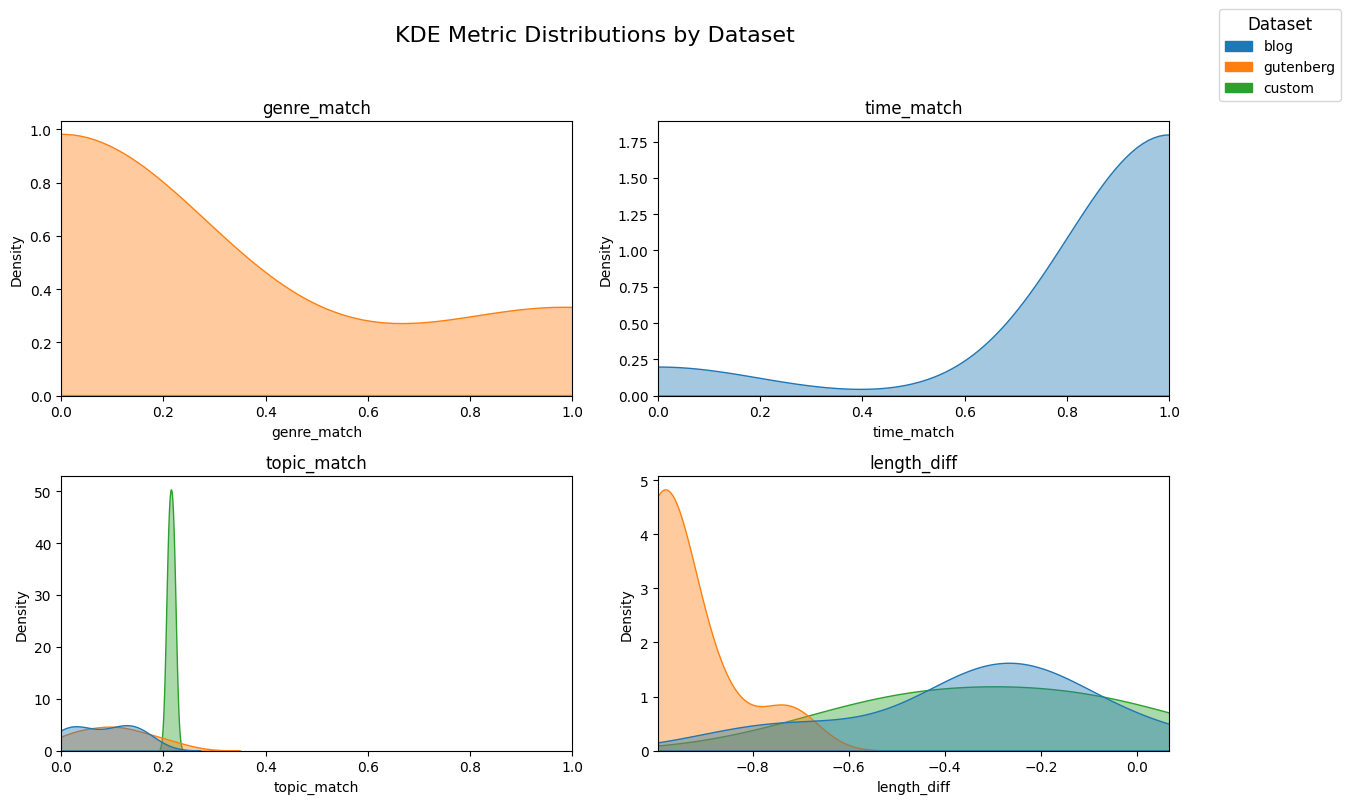

In [ ]:
metrics = ["genre_match", "time_match", "topic_match", "length_diff"]
save_path = path2results
plot_metric_kdes_per_dataset(df_all, metrics, save_path=path2results)

`length_diff` is perceptual difference in length between original and paraphrased text, where negative values indicate that the paraphrased text is shorter than the original text.

## Batch Processing

In [ ]:
# Batch paraphrasing
# texts = ["The sky is blue.", "I love programming.", "Artificial intelligence is fascinating."]
# paraphrased_batch = bullet_point_paraphraser.paraphrase_batch(texts)
# for original, paraphrased in zip(texts, paraphrased_batch):
#     print(f"Original: {original} | Paraphrased: {paraphrased}")

In [ ]:
import dirtyjson

d = dirtyjson.loads(
    """["foo", /* not fu*/ {bar: ['baz', null, 1.0, 2,]}] and then ignore this junk"""
)
d

['foo', AttributedDict([('bar', ['baz', None, 1.0, 2])])]